### **Exploratory Data Analysis (EDA)**

This analysis prepares a dataset for a **human–AI decision support system (DSS)** focused on loan approval decisions. The objective is not purely predictive performance, but the construction of a **controlled, interpretable decision environment** suitable for behavioral experimentation.

The EDA serves three purposes:

1. **Feature Space Construction** — justify the final feature list fixed in `feature_config.py`
2. **Case Design for Experimentation** — derive difficulty tiers from train-only empirical base rates
3. **Experimental Validity** — verify temporal stability and distribution shift

---

**Scope note**

Missingness checks, univariate default-rate plots, and correlation analysis use the **full dataset** for descriptive context. All transformations used in modeling and difficulty scoring (bin edges, smoothed base rates) are estimated on the **training set only** (pre-2016) and applied to other splits without re-fitting. Feature selection is fixed in `feature_config.py`; the EDA below justifies those choices but does not change them.

---

**Dataset Overview**

- **Target**: `target = 1` (Charged Off), `0` (Fully Paid)
- **Time span**: 2007–2018 loan issuance dates
- **Default rate**: ≈ 20% (moderate imbalance, preserved intentionally)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from pandas.api.types import is_numeric_dtype
import json
import os
import sys
from pathlib import Path

np.random.seed(42)
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT      = Path.cwd().parents[1]          # capstone/
DATA_RAW  = ROOT / "data" / "raw" / "loan.csv"
DATA_PROC = ROOT / "data" / "processed" / "loan_v1.csv"
ARTIFACTS = ROOT / "artifacts"
FIGS_DIR  = ROOT / "codes" / "visualizations"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Set False to suppress figure saving (outputs still display inline)
SAVE_FIGS = True

sys.path.append(str(ROOT / "codes"))

from data_prep import load_and_clean, build_features
from feature_config import NUM_COLS, FEATURES, TARGET

print("ROOT     :", ROOT)
print("FIGS_DIR :", FIGS_DIR)
print("Working  :", Path.cwd())

ROOT     : /Users/annaasatryan/Desktop/capstone
FIGS_DIR : /Users/annaasatryan/Desktop/capstone/codes/visualizations
Working  : /Users/annaasatryan/Desktop/capstone/codes/notebooks


**Data loading**

In [2]:
df = load_and_clean(DATA_RAW)

print("\nShape:", df.shape)
print("Columns:", len(df.columns))
print("\nTime range:", df['issue_d'].min(), "→", df['issue_d'].max())
print("\nDefault rate:", df['target'].mean())

print("\nMissing (top 10):")
print(df.isna().mean().sort_values(ascending=False).head(10))


Shape: (1300076, 131)
Columns: 131

Time range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00

Default rate: 0.2008374895006138

Missing (top 10):
id                                            1.000000
url                                           1.000000
member_id                                     1.000000
orig_projected_additional_accrued_interest    0.997359
payment_plan_start_date                       0.995898
hardship_end_date                             0.995898
hardship_type                                 0.995898
hardship_reason                               0.995898
hardship_status                               0.995898
deferral_term                                 0.995898
dtype: float64


**Domain-driven candidate features**

In [3]:
df = build_features(df)

candidate_features = [
    # loan structure
    'loan_amnt',
    'term',
    'int_rate',
    'installment',

    # borrower profile
 #   'annual_inc',
    'log_annual_inc', 
    'home_ownership',
    'purpose',

    # credit behavior
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'pub_rec_bankruptcies',
    'credit_history_years',
    'revol_util',
    'open_acc',
]

candidate_features = [c for c in candidate_features if c in df.columns]

print("\nInitial candidates:", candidate_features)


Initial candidates: ['loan_amnt', 'term', 'int_rate', 'installment', 'log_annual_inc', 'home_ownership', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec_bankruptcies', 'credit_history_years', 'revol_util', 'open_acc']


**Missingness filter**

In [4]:
missing = df[candidate_features].isna().mean().sort_values(ascending=False)
print("\nMissingness:")
print(missing)

candidate_features = [c for c in candidate_features if missing[c] < 0.4]

print("\nAfter missing filter:", candidate_features)


Missingness:
revol_util              6.184254e-04
pub_rec_bankruptcies    5.076626e-04
dti                     2.399860e-04
inq_last_6mths          7.691858e-07
loan_amnt               0.000000e+00
term                    0.000000e+00
int_rate                0.000000e+00
installment             0.000000e+00
log_annual_inc          0.000000e+00
home_ownership          0.000000e+00
purpose                 0.000000e+00
delinq_2yrs             0.000000e+00
credit_history_years    0.000000e+00
open_acc                0.000000e+00
dtype: float64

After missing filter: ['loan_amnt', 'term', 'int_rate', 'installment', 'log_annual_inc', 'home_ownership', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec_bankruptcies', 'credit_history_years', 'revol_util', 'open_acc']


Missingness across candidate features is negligible (<0.1% for all retained variables). Simple imputation (median for numeric, mode for categorical variables) is sufficient and does not materially affect model calibration or downstream experimental validity.

**Removing constant features**

In [5]:
def is_constant(series):
    return series.nunique() <= 1

candidate_features = [
    c for c in candidate_features
    if not is_constant(df[c])
]

print("\nAfter constant filter:", candidate_features)


After constant filter: ['loan_amnt', 'term', 'int_rate', 'installment', 'log_annual_inc', 'home_ownership', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec_bankruptcies', 'credit_history_years', 'revol_util', 'open_acc']


A constant-feature filter is applied as a safeguard to remove degenerate variables with no variance.

**Univariate analysis**


--- loan_amnt ---
bin
(499.999, 6500.0]     0.159691
(6500.0, 10000.0]     0.176997
(10000.0, 15000.0]    0.208689
(15000.0, 21000.0]    0.228173
(21000.0, 40000.0]    0.234845
Name: target, dtype: float64


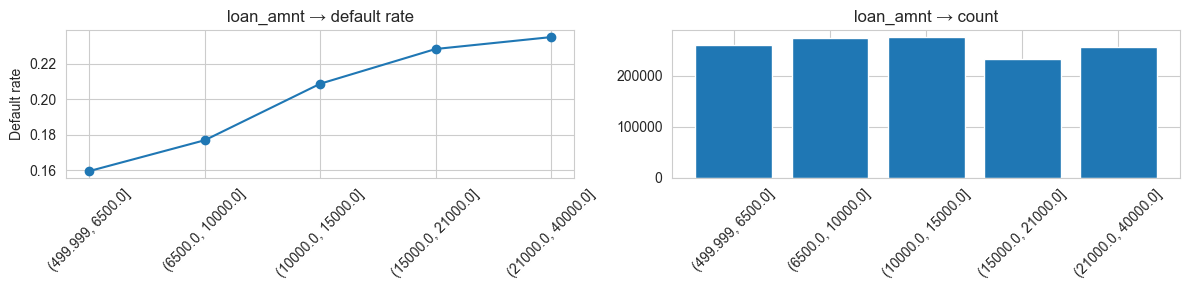


--- term ---
term
36 months    0.161015
60 months    0.325730
Name: target, dtype: float64


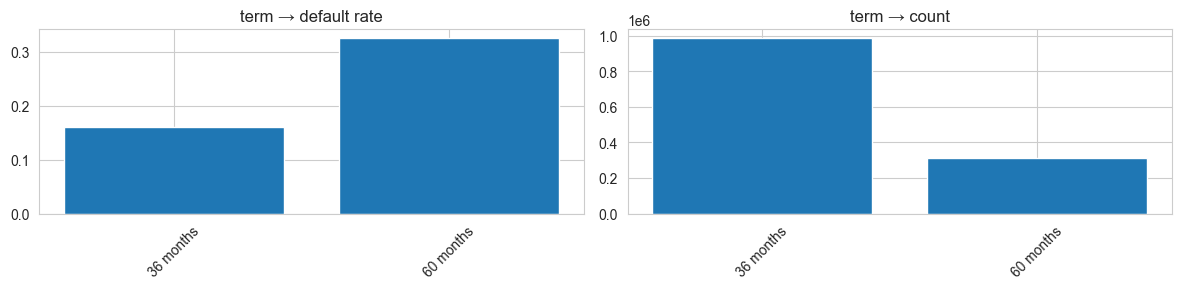


--- int_rate ---
bin
(5.308999999999999, 8.9]    0.067682
(8.9, 11.53]                0.138773
(11.53, 13.99]              0.194654
(13.99, 16.99]              0.251194
(16.99, 30.99]              0.360640
Name: target, dtype: float64


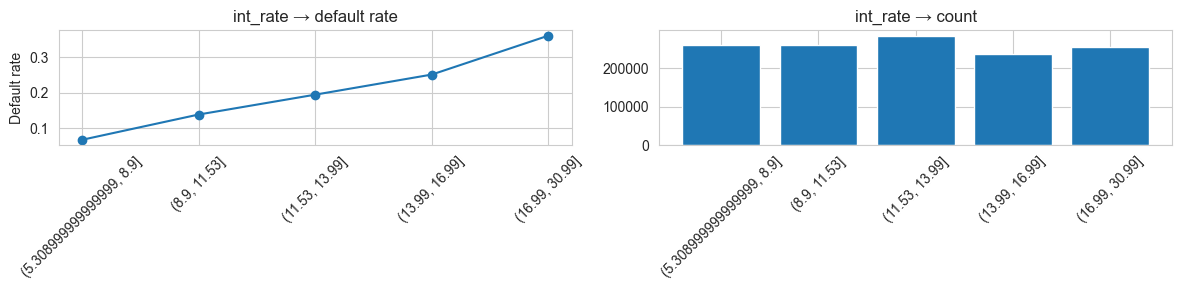


--- installment ---
bin
(4.928999999999999, 217.4]    0.154287
(217.4, 324.98]               0.191199
(324.98, 451.9]               0.217110
(451.9, 640.58]               0.219550
(640.58, 1719.83]             0.222087
Name: target, dtype: float64


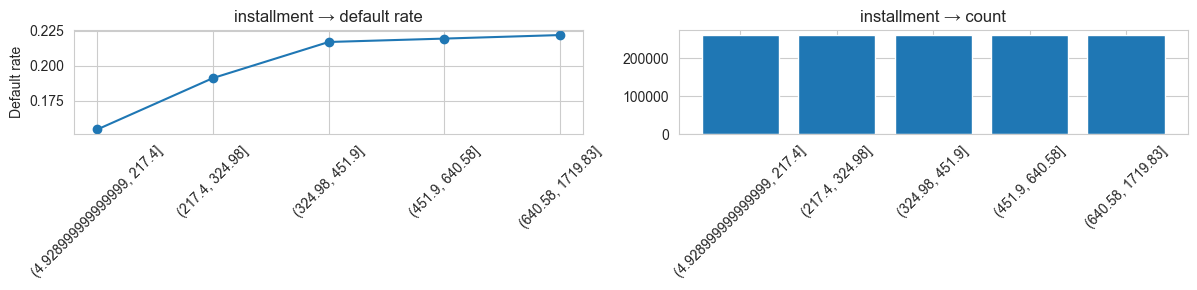


--- log_annual_inc ---
bin
(-0.001, 10.645]    0.236732
(10.645, 10.951]    0.217210
(10.951, 11.212]    0.204306
(11.212, 11.513]    0.185133
(11.513, 16.213]    0.158039
Name: target, dtype: float64


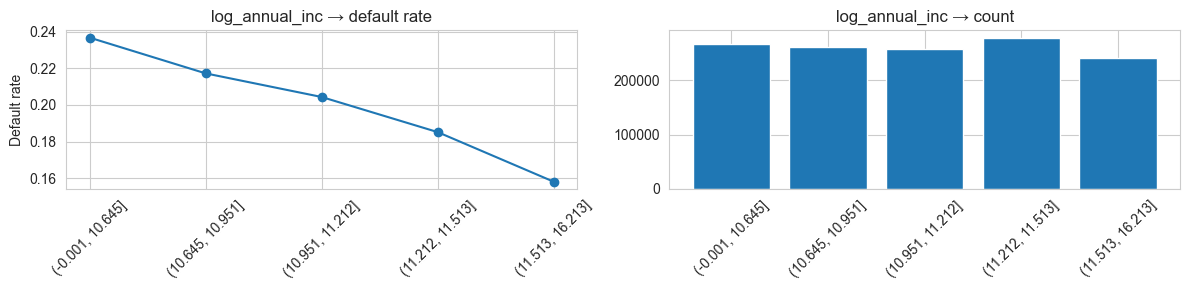


--- home_ownership ---
home_ownership
ANY         0.194757
MORTGAGE    0.173030
NONE        0.145833
OTHER       0.194245
OWN         0.207565
RENT        0.233765
Name: target, dtype: float64


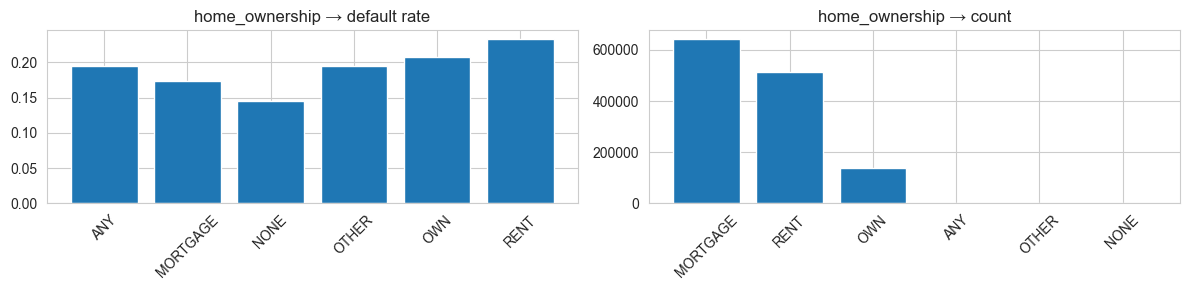


--- purpose ---
purpose
car                   0.146388
credit_card           0.170267
debt_consolidation    0.212567
home_improvement      0.178531
house                 0.217167
major_purchase        0.187235
medical               0.219064
moving                0.234409
other                 0.211706
small_business        0.297468
vacation              0.192396
Name: target, dtype: float64


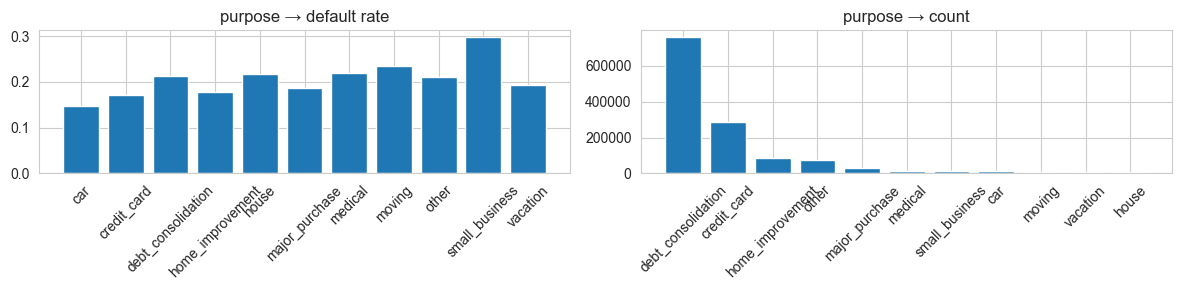


--- dti ---
bin
(-1.001, 10.5]    0.149530
(10.5, 15.33]     0.168552
(15.33, 19.98]    0.192321
(19.98, 25.68]    0.220839
(25.68, 999.0]    0.273090
Name: target, dtype: float64


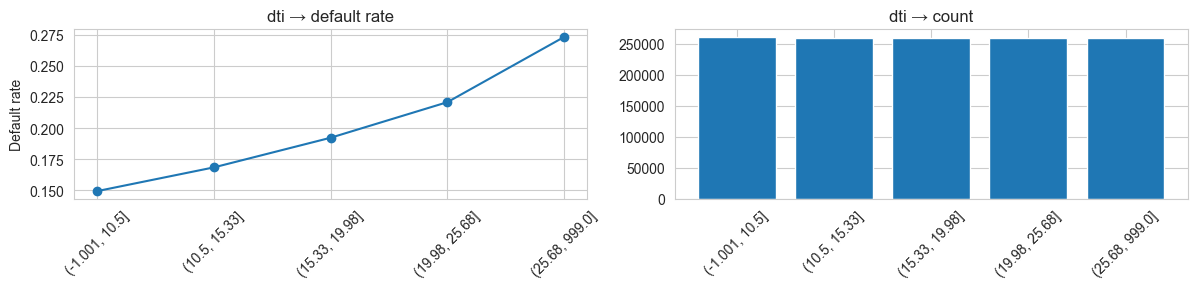


--- delinq_2yrs ---
bin
(-0.001, 39.0]    0.200837
Name: target, dtype: float64


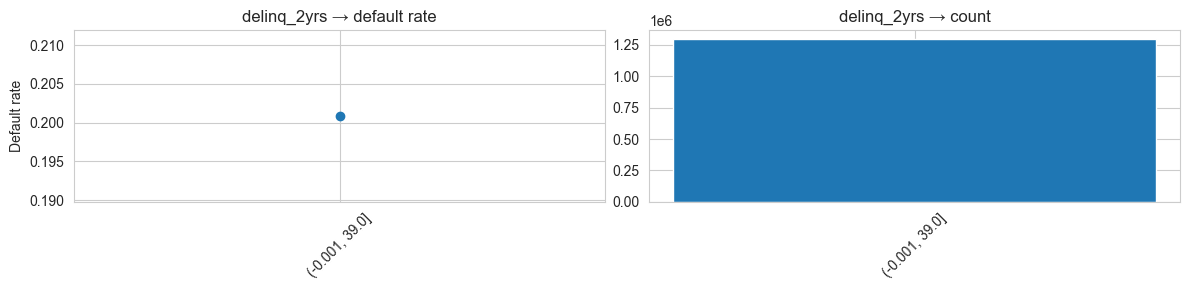


--- inq_last_6mths ---
bin
(-0.001, 1.0]    0.191730
(1.0, 8.0]       0.250167
Name: target, dtype: float64


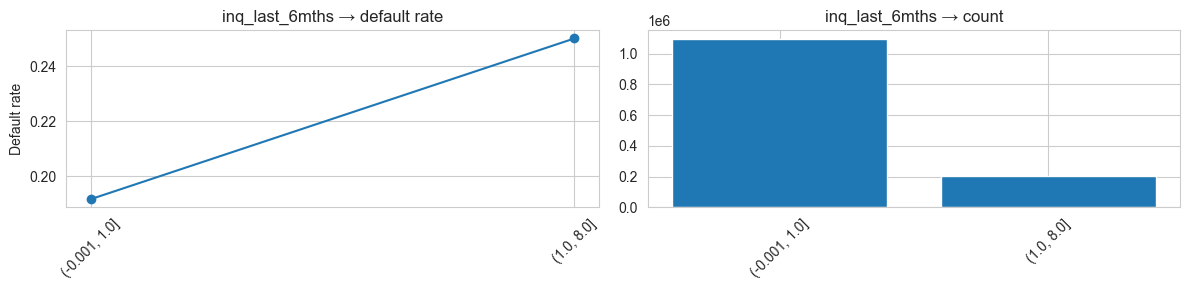


--- pub_rec_bankruptcies ---
bin
(-0.001, 12.0]    0.200853
Name: target, dtype: float64


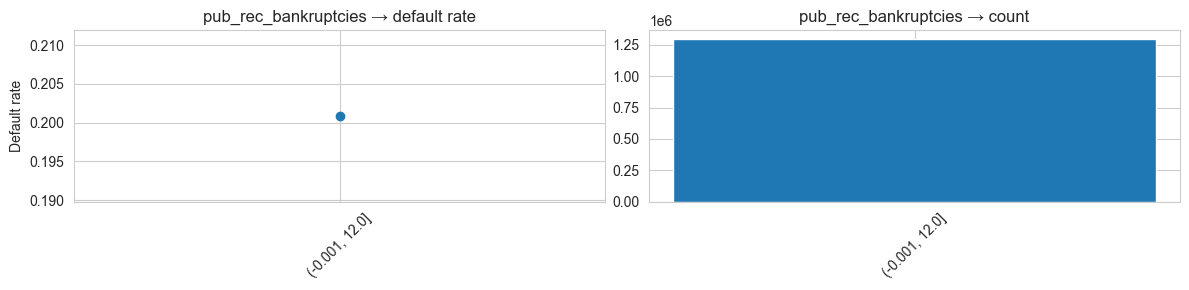


--- credit_history_years ---
bin
(2.9970000000000003, 10.42]    0.222339
(10.42, 13.328]                0.213994
(13.328, 16.498]               0.197919
(16.498, 21.582]               0.190151
(21.582, 83.25]                0.179733
Name: target, dtype: float64


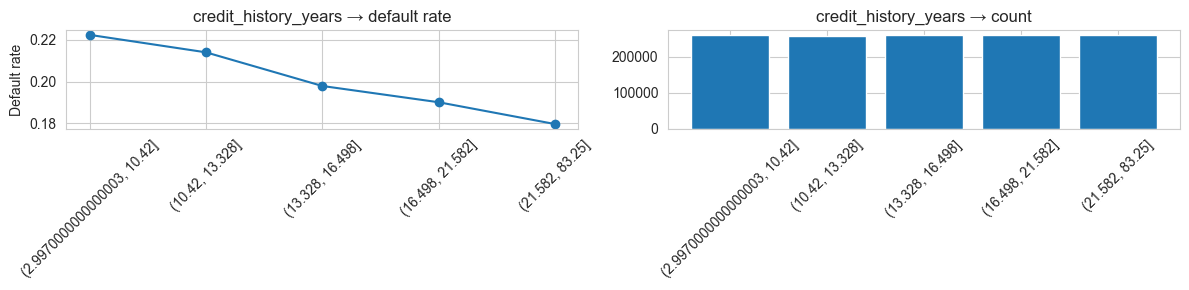


--- revol_util ---
bin
(-0.001, 29.2]    0.158371
(29.2, 45.1]      0.191146
(45.1, 59.4]      0.208644
(59.4, 75.1]      0.218329
(75.1, 892.3]     0.227809
Name: target, dtype: float64


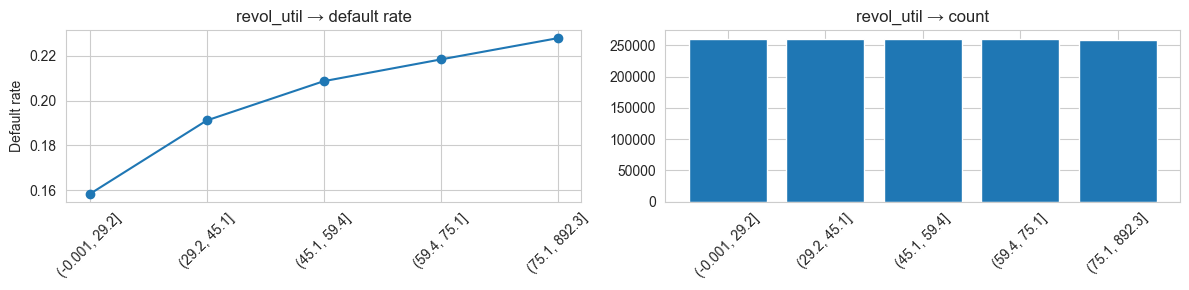


--- open_acc ---
bin
(-0.001, 7.0]    0.186035
(7.0, 9.0]       0.193504
(9.0, 12.0]      0.202872
(12.0, 15.0]     0.206650
(15.0, 90.0]     0.217280
Name: target, dtype: float64


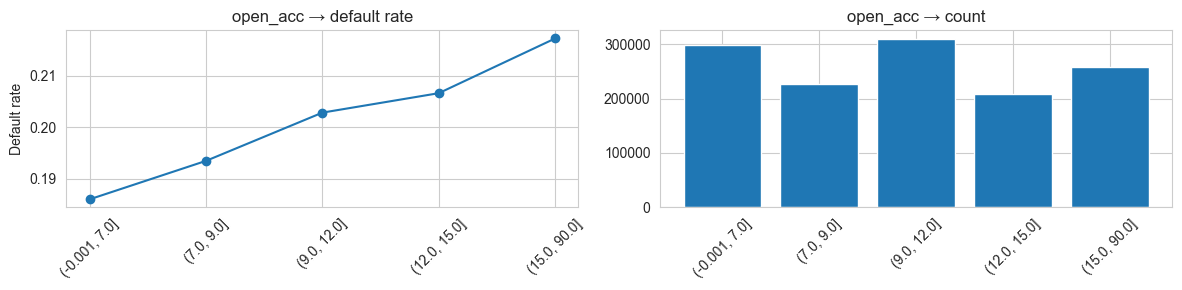

In [6]:
def analyze_feature(df, feature, bins=5):
    """Print binned default rates. Save figure to FIGS_DIR when SAVE_FIGS=True."""
    df_temp = df[[feature, 'target']].dropna().copy()
    print(f"\n--- {feature} ---")

    if df_temp[feature].dtype in ['float64', 'int64']:
        df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
        agg = df_temp.groupby('bin', observed=True)['target'].mean()
        counts = df_temp['bin'].value_counts().sort_index()
        print(agg)

        if SAVE_FIGS:
            x = range(len(agg))
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
            ax1.plot(x, agg.values, marker='o')
            ax1.set_xticks(list(x))
            ax1.set_xticklabels(agg.index.astype(str), rotation=45)
            ax1.set_title(f"{feature} → default rate")
            ax1.set_ylabel("Default rate")
            ax2.bar(x, counts.values)
            ax2.set_xticks(list(x))
            ax2.set_xticklabels(counts.index.astype(str), rotation=45)
            ax2.set_title(f"{feature} → count")
            plt.tight_layout()
            plt.show()
    else:
        agg = df_temp.groupby(feature, observed=True)['target'].mean()
        counts = df_temp[feature].value_counts()
        print(agg)

        if SAVE_FIGS:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
            ax1.bar(range(len(agg)), agg.values)
            ax1.set_xticks(range(len(agg)))
            ax1.set_xticklabels(agg.index.astype(str), rotation=45)
            ax1.set_title(f"{feature} → default rate")
            ax2.bar(range(len(counts)), counts.values)
            ax2.set_xticks(range(len(counts)))
            ax2.set_xticklabels(counts.index.astype(str), rotation=45)
            ax2.set_title(f"{feature} → count")
            plt.tight_layout()
            plt.show()


for f in candidate_features:
    analyze_feature(df, f)

**Categorical features vs target**

In [7]:
print("\n=== Categorical Features vs Target ===")

cat_cols = ['purpose', 'home_ownership', 'term']

for col in cat_cols:
    print(f"\n--- {col} ---")
    summary = (
        df.groupby(col, observed=True)['target']
        .agg(['mean','count'])
        .sort_values('mean', ascending=False)
    )
    print(summary)


=== Categorical Features vs Target ===

--- purpose ---
                        mean   count
purpose                             
small_business      0.297468   15010
moving              0.234409    9172
medical             0.219064   15023
house               0.217167    6967
debt_consolidation  0.212567  757591
other               0.211706   74934
vacation            0.192396    8732
major_purchase      0.187235   28328
home_improvement    0.178531   84495
credit_card         0.170267  285704
car                 0.146388   14120

--- home_ownership ---
                    mean   count
home_ownership                  
RENT            0.233765  515761
OWN             0.207565  139561
ANY             0.194757     267
OTHER           0.194245     139
MORTGAGE        0.173030  644300
NONE            0.145833      48

--- term ---
               mean   count
term                       
60 months  0.325730  314316
36 months  0.161015  985760


**Correlation check**

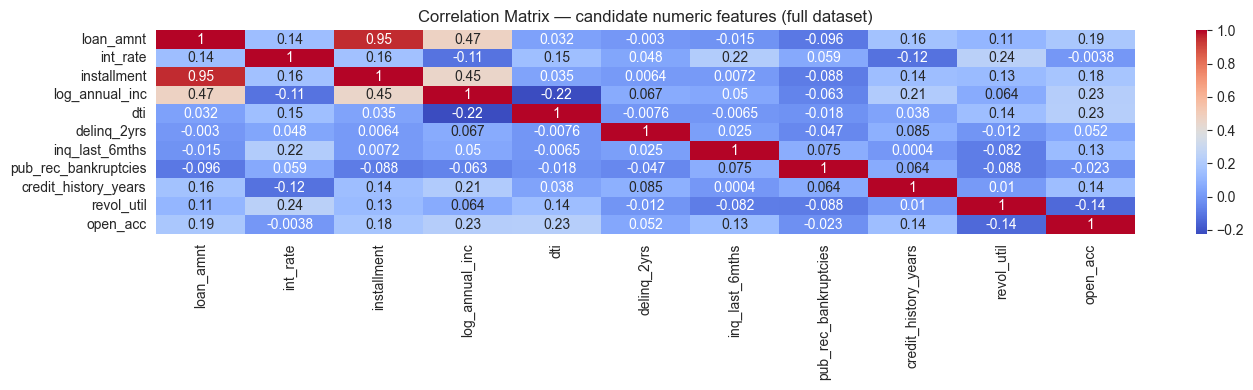

In [8]:
numeric_features = [c for c in candidate_features if is_numeric_dtype(df[c])]

corr = df[numeric_features].corr()

if SAVE_FIGS:
    plt.figure(figsize=(14, 4))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix — candidate numeric features (full dataset)")
    plt.tight_layout()
    plt.show()

The correlation matrix is used to identify redundancy between features rather than predictive strength.
A strong correlation is observed between loan_amnt and installment (ρ ≈ 0.95), confirming that installment is functionally derived from loan structure variables.
No other pairs exhibit high correlation, indicating low multicollinearity among retained features.

**Spearman**

In [9]:
results = []

for col in NUM_COLS:
    valid = df[[col, 'target']].dropna()
    corr, pval = spearmanr(valid[col], valid['target'])
    results.append((col, corr, pval))

spearman_df = pd.DataFrame(results, columns=['feature','spearman_corr','p_value'])

print(spearman_df.sort_values('spearman_corr', key=abs, ascending=False))

                feature  spearman_corr  p_value
1              int_rate       0.254142      0.0
3                   dti       0.108542      0.0
0             loan_amnt       0.070226      0.0
2        log_annual_inc      -0.067729      0.0
5            revol_util       0.060362      0.0
4  credit_history_years      -0.039248      0.0


Spearman rank correlation is used to assess monotonic relationships between features and default risk.
The strongest relationship is observed for int_rate (ρ ≈ 0.25), followed by dti and loan_amnt, indicating moderate predictive signal.

These results are used jointly with univariate analysis to guide feature selection.

**Feature interaction check**

=== RATE × DTI DEFAULT RATES (train) ===

rate_q        Low rate  Med-low rate  Med-high rate  High rate
dti_q                                                         
Low DTI          0.055         0.118          0.173      0.260
Med-low DTI      0.064         0.133          0.193      0.298
Med-high DTI     0.077         0.151          0.215      0.326
High DTI         0.092         0.172          0.248      0.378

=== RATE × INCOME DEFAULT RATES (train) ===

rate_q        Low rate  Med-low rate  Med-high rate  High rate
inc_q                                                         
Low income       0.091         0.161          0.227      0.334
Med-low inc      0.075         0.144          0.218      0.346
Med-high inc     0.066         0.138          0.202      0.324
High income      0.056         0.125          0.179      0.279


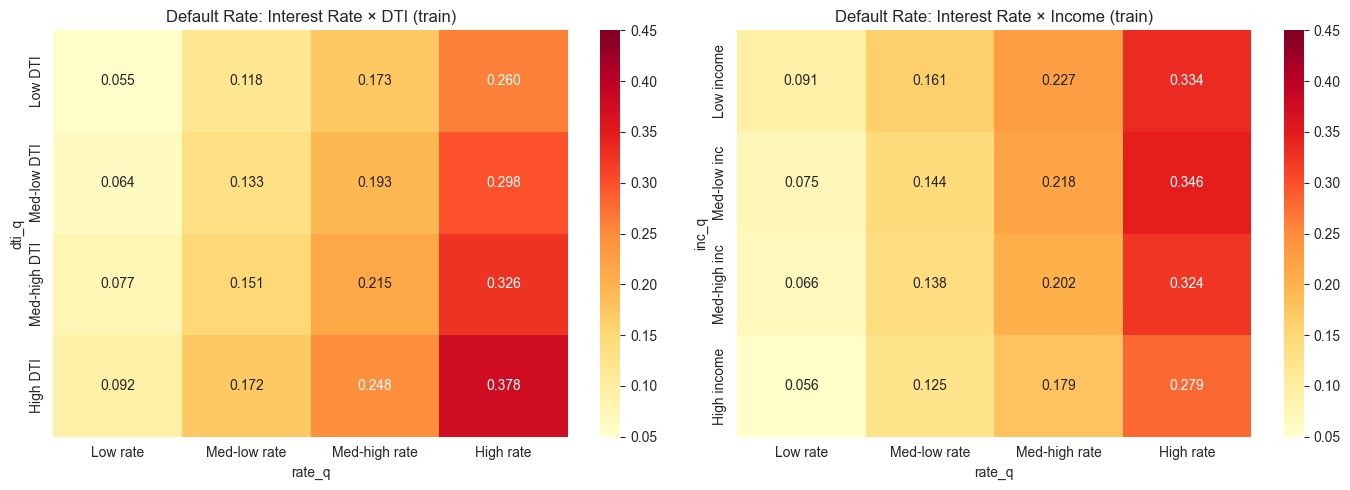


=== INTERACTION STRENGTH ===
Additive prediction (high rate + high DTI): 0.3825
Actual observed (high rate + high DTI):     0.3780
Interaction effect (actual - additive):     -0.0045

→ Approximately additive. 3D construction conservative but defensible.


In [10]:
# Feature interaction analysis — uses TRAINING data only (pre-2016)
train_interaction = df[df['issue_d'] < '2016-01-01'].copy()

train_interaction['rate_q'] = pd.qcut(train_interaction['int_rate'], q=4,
                                       labels=['Low rate', 'Med-low rate', 'Med-high rate', 'High rate'])
train_interaction['dti_q']  = pd.qcut(train_interaction['dti'], q=4,
                                       labels=['Low DTI', 'Med-low DTI', 'Med-high DTI', 'High DTI'])
train_interaction['inc_q']  = pd.qcut(train_interaction['log_annual_inc'], q=4,
                                       labels=['Low income', 'Med-low inc', 'Med-high inc', 'High income'])

rate_dti_grid = train_interaction.pivot_table(
    values='target', index='dti_q', columns='rate_q',
    aggfunc='mean', observed=True
).round(3)

print("=== RATE × DTI DEFAULT RATES (train) ===\n")
print(rate_dti_grid.to_string())

rate_inc_grid = train_interaction.pivot_table(
    values='target', index='inc_q', columns='rate_q',
    aggfunc='mean', observed=True
).round(3)

print("\n=== RATE × INCOME DEFAULT RATES (train) ===\n")
print(rate_inc_grid.to_string())

if SAVE_FIGS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(rate_dti_grid, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0], vmin=0.05, vmax=0.45)
    axes[0].set_title('Default Rate: Interest Rate × DTI (train)')
    sns.heatmap(rate_inc_grid, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], vmin=0.05, vmax=0.45)
    axes[1].set_title('Default Rate: Interest Rate × Income (train)')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / "feature_interactions.png", dpi=150, bbox_inches='tight')
    plt.show()

# Interaction strength
marginal_rate = train_interaction.groupby('rate_q', observed=True)['target'].mean()
marginal_dti  = train_interaction.groupby('dti_q',  observed=True)['target'].mean()
global_mean   = train_interaction['target'].mean()

additive_prediction = global_mean + (marginal_rate.iloc[-1] - global_mean) + (marginal_dti.iloc[-1] - global_mean)
actual_joint        = rate_dti_grid.iloc[-1, -1]

print("\n=== INTERACTION STRENGTH ===")
print(f"Additive prediction (high rate + high DTI): {additive_prediction:.4f}")
print(f"Actual observed (high rate + high DTI):     {actual_joint:.4f}")
print(f"Interaction effect (actual - additive):     {actual_joint - additive_prediction:+.4f}")

if abs(actual_joint - additive_prediction) > 0.02:
    print("\n→ Super-additive interaction. 3D difficulty construction justified.")
else:
    print("\n→ Approximately additive. 3D construction conservative but defensible.")

Feature interaction analysis confirmed that default risk is approximately additive across interest rate, DTI, and income dimensions, indicating that the multi-dimensional difficulty construction provides stable estimates without relying on complex interaction patterns.

**Feature decisions**

In [11]:
redundant_features    = ['installment']
low_signal_features   = ['delinq_2yrs', 'pub_rec_bankruptcies']
parsimony_exclusions  = ['inq_last_6mths', 'open_acc']

remove_features = set(redundant_features + low_signal_features + parsimony_exclusions)

final_features = [f for f in candidate_features if f not in remove_features]
print("Derived final features:", final_features)

# feature_config.py is authoritative — verify EDA derivation matches
assert set(final_features) == set(FEATURES), (
    f"feature_config.py is out of sync!\n"
    f"  EDA derives: {sorted(final_features)}\n"
    f"  Config has : {sorted(FEATURES)}\n"
    "Update feature_config.py to match."
)
print("✓ feature_config.py consistent with EDA derivation")

Derived final features: ['loan_amnt', 'term', 'int_rate', 'log_annual_inc', 'home_ownership', 'purpose', 'dti', 'credit_history_years', 'revol_util']
✓ feature_config.py consistent with EDA derivation


**Feature Selection and Justification**

Each feature is retained only if it satisfies all of the following:

1. **Available at decision time**  
   Features must be observable before the lending decision (no post-outcome leakage).

2. **Interpretability**  
   Features must be understandable to human participants in the DSS.

3. **Stable relationship with target**  
   The feature should show a consistent (ideally monotonic) relationship with default risk in EDA.

4. **Non-redundancy**  
   Features that are highly correlated or functionally derived from others are removed.

---

#### 1. Redundant Feature

- **`installment` removed**

Reason:
- Highly correlated with `loan_amnt`
- Functionally determined by (`loan_amnt`, `term`, `int_rate`)

Implication:
- Adds no independent information
- Keeping it would introduce multicollinearity and distort interpretability

---

#### 2. Near–No-Signal Features

- **`delinq_2yrs` removed**
- **`pub_rec_bankruptcies` removed**

Reason:
- Flat or near-constant default rate across bins in EDA
- No meaningful discriminative power

Implication:
- Including them adds noise without improving predictive or experimental value

---

#### 3. Moderate-Signal but Excluded for Parsimony

The following features showed some predictive signal but were excluded to reduce
feature space complexity and cognitive burden in the decision support system:

- **`inq_last_6mths` removed**
  - Limited resolution (few distinct values)
  - Weak and unstable relationship with default risk

- **`open_acc` removed**
  - Weak monotonic trend
  - Overlaps conceptually with broader credit capacity indicators

Reason:
- These features provide marginal incremental value relative to stronger predictors
- Including them increases dimensionality without meaningful gain in interpretability or experimental clarity

---

#### 4. Final Retained Features

The final feature set includes only variables with:
- clear directional signal
- intuitive meaning
- non-redundant information content

**Loan structure**
- `loan_amnt`, `term`, `int_rate`

**Borrower profile**
- `log_annual_inc`, `home_ownership`, `purpose`

**Credit behavior**
- `dti`, `credit_history_years`, `revol_util`

---

We deliberately favor a **compact, high-signal feature set** to:

- ensure participants can process information without overload  
- preserve interpretability of decisions  
- isolate the effect of interaction protocols rather than feature complexity  

This aligns with the objective of evaluating **human–AI interaction**, not maximizing predictive performance.


**Temporal split**

In [12]:
train = df[df['issue_d'] < "2016-01-01"].copy()
test  = df[df['issue_d'] >= "2016-01-01"].copy()

print("\nTrain default:", train['target'].mean())
print("Test default:", test['target'].mean())
print("Shift:", test['target'].mean() - train['target'].mean())


Train default: 0.18448195087671354
Test default: 0.228741694836228
Shift: 0.04425974395951446


Temporal distribution shift introduces distribution shift that may affect calibration

**Default rate over time**

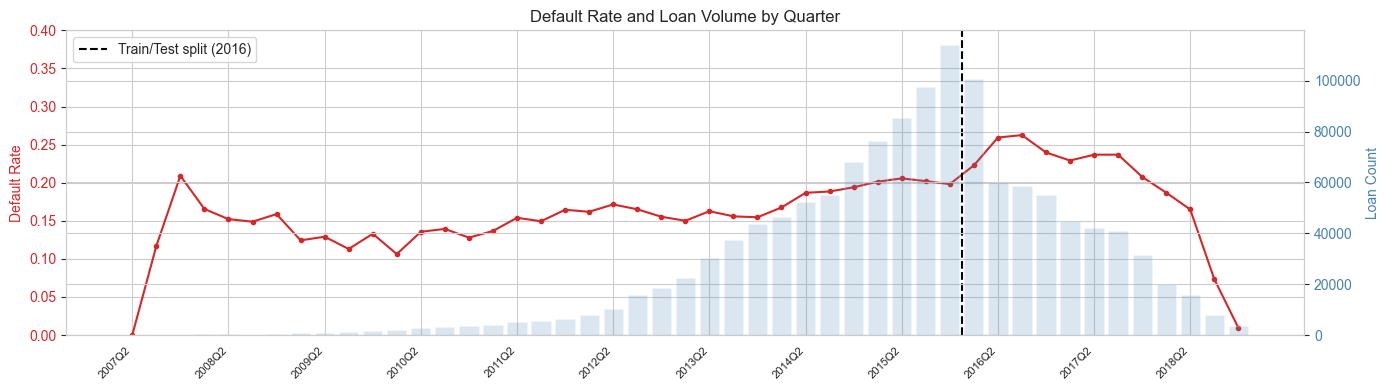

=== DEFAULT RATE BY YEAR ===

            default_rate  n_loans
issue_year                       
2007            0.177489      231
2008            0.158936     1466
2009            0.125622     4418
2010            0.129334    11134
2011            0.152639    21161
2012            0.162405    52560
2013            0.155986   134147
2014            0.185378   221342
2015            0.201555   373193
2016            0.242661   274498
2017            0.228912   158777
2018            0.147129    47149

Train period mean: 0.1845
Test period mean:  0.2287


In [13]:
df['issue_quarter'] = df['issue_d'].dt.to_period('Q')

quarterly = (
    df.groupby('issue_quarter')['target']
    .agg(['mean', 'count'])
    .reset_index()
)
quarterly['issue_quarter'] = quarterly['issue_quarter'].astype(str)

if SAVE_FIGS:
    fig, ax1 = plt.subplots(figsize=(14, 4))

    color_rate = '#d62728'
    ax1.plot(range(len(quarterly)), quarterly['mean'], color=color_rate, linewidth=1.5, marker='o', markersize=3)
    ax1.set_ylabel('Default Rate', color=color_rate)
    ax1.tick_params(axis='y', labelcolor=color_rate)
    ax1.set_ylim(0, 0.40)

    ax2 = ax1.twinx()
    ax2.bar(range(len(quarterly)), quarterly['count'], alpha=0.2, color='steelblue')
    ax2.set_ylabel('Loan Count', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')

    train_end_idx = len(quarterly[quarterly['issue_quarter'] < '2016Q1']) - 1
    ax1.axvline(train_end_idx + 0.5, color='black', linestyle='--', linewidth=1.5, label='Train/Test split (2016)')

    tick_positions = range(0, len(quarterly), 4)
    tick_labels = [quarterly['issue_quarter'].iloc[i] for i in tick_positions]
    ax1.set_xticks(list(tick_positions))
    ax1.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax1.set_title('Default Rate and Loan Volume by Quarter')
    ax1.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(FIGS_DIR / "default_rate_over_time.png", dpi=150, bbox_inches='tight')
    plt.show()

print("=== DEFAULT RATE BY YEAR ===\n")
df['issue_year'] = df['issue_d'].dt.year
yearly = df.groupby('issue_year')['target'].agg(['mean', 'count'])
yearly.columns = ['default_rate', 'n_loans']
print(yearly.to_string())
print(f"\nTrain period mean: {df[df['issue_d'] < '2016-01-01']['target'].mean():.4f}")
print(f"Test period mean:  {df[df['issue_d'] >= '2016-01-01']['target'].mean():.4f}")

**Binning (train-derived)**

Bin edges are computed on the training set only (pre-2016). The same edges are then applied to test and the full dataset for export — no re-fitting on unseen data.

In [14]:
bin_edges = {}

_, edges = pd.qcut(
    train['log_annual_inc'],
    q=5,
    retbins=True,
    duplicates='drop'
)
bin_edges['income'] = edges

_, edges = pd.qcut(
    train['loan_amnt'],
    q=4,
    retbins=True,
    duplicates='drop'
)
bin_edges['loan'] = edges

_, edges = pd.qcut(
    train['int_rate'],
    q=4,
    retbins=True,
    duplicates='drop'
)
bin_edges['rate'] = edges

_, edges = pd.qcut(
    train['dti'],
    q=4,
    retbins=True,
    duplicates='drop'
)
bin_edges['dti'] = edges

In [15]:
def apply_bins(df, bin_edges):
    df = df.copy()
    
    # Extend edges to capture out-of-range values
    def open_edges(edges):
        e = edges.copy()
        e[0] = -np.inf
        e[-1] = np.inf
        return e
    
    df['income_bin'] = pd.cut(df['log_annual_inc'], 
                               bins=open_edges(bin_edges['income']),
                               include_lowest=True)
    df['loan_bin'] = pd.cut(df['loan_amnt'],
                             bins=open_edges(bin_edges['loan']),
                             include_lowest=True)
    df['rate_bin'] = pd.cut(df['int_rate'],
                             bins=open_edges(bin_edges['rate']),
                             include_lowest=True)
    df['dti_bin'] = pd.cut(df['dti'],
                            bins=open_edges(bin_edges['dti']),
                            include_lowest=True)
    return df

# Apply everywhere
train = apply_bins(train, bin_edges)
test = apply_bins(test, bin_edges)
df = apply_bins(df, bin_edges)

**Bin reliability**

In [16]:
for col in ['income_bin', 'loan_bin', 'rate_bin', 'dti_bin']:
    print(f"\n=== {col} ===")
    print(
        train
        .groupby(col, observed=True)['target']
        .agg(['mean', 'count'])
    )


=== income_bin ===
                      mean   count
income_bin                        
(-inf, 10.645]    0.215146  174305
(10.645, 10.915]  0.202768  154842
(10.915, 11.184]  0.190546  167057
(11.184, 11.493]  0.169284  161557
(11.493, inf]     0.142886  161891

=== loan_bin ===
                        mean   count
loan_bin                            
(-inf, 8000.0]      0.145539  222380
(8000.0, 12000.0]   0.177131  189137
(12000.0, 20000.0]  0.204499  233409
(20000.0, inf]      0.215263  174726

=== rate_bin ===
                    mean   count
rate_bin                        
(-inf, 9.76]    0.068912  205698
(9.76, 12.99]   0.142919  220397
(12.99, 15.88]  0.209188  190412
(15.88, inf]    0.323439  203145

=== dti_bin ===
                   mean   count
dti_bin                        
(-inf, 11.78]  0.137226  204997
(11.78, 17.5]  0.163951  205147
(17.5, 23.76]  0.193332  204777
(23.76, inf]   0.243517  204729


**Stability check**

In [17]:
for col in ['income_bin', 'loan_bin', 'rate_bin', 'dti_bin']:
    print(f"\n=== {col} ===")

    print("Train:")
    print(
        train
        .groupby(col, observed=True)['target']
        .mean()
    )

    print("Test:")
    print(
        test
        .groupby(col, observed=True)['target']
        .mean()
    )


=== income_bin ===
Train:
income_bin
(-inf, 10.645]      0.215146
(10.645, 10.915]    0.202768
(10.915, 11.184]    0.190546
(11.184, 11.493]    0.169284
(11.493, inf]       0.142886
Name: target, dtype: float64
Test:
income_bin
(-inf, 10.645]      0.278072
(10.645, 10.915]    0.246001
(10.915, 11.184]    0.230566
(11.184, 11.493]    0.214468
(11.493, inf]       0.185864
Name: target, dtype: float64

=== loan_bin ===
Train:
loan_bin
(-inf, 8000.0]        0.145539
(8000.0, 12000.0]     0.177131
(12000.0, 20000.0]    0.204499
(20000.0, inf]        0.215263
Name: target, dtype: float64
Test:
loan_bin
(-inf, 8000.0]        0.187304
(8000.0, 12000.0]     0.221538
(12000.0, 20000.0]    0.250832
(20000.0, inf]        0.266383
Name: target, dtype: float64

=== rate_bin ===
Train:
rate_bin
(-inf, 9.76]      0.068912
(9.76, 12.99]     0.142919
(12.99, 15.88]    0.209188
(15.88, inf]      0.323439
Name: target, dtype: float64
Test:
rate_bin
(-inf, 9.76]      0.094704
(9.76, 12.99]     0.188895
(1

**Case difficulty for experiment**

In [18]:
# Difficulty construction
#
# Design choices:
#   - Model-independent (empirical base rates, no model predictions)
#   - Multi-dimensional (rate × dti × income)
#   - Bayesian smoothing toward global mean (reduces noise in sparse bins)
#   - All statistics estimated on TRAINING SET ONLY — applied to other splits without re-fitting

BIN_COLS = ['rate_bin', 'dti_bin', 'income_bin']

# 1. Bin statistics on TRAIN only
bin_stats = (
    train
    .groupby(BIN_COLS, observed=True)
    .agg(bin_count=(TARGET, 'size'), bin_mean=(TARGET, 'mean'))
)

# 2. Bayesian smoothing
global_mean = train[TARGET].mean()
alpha = 50

bin_stats['smoothed_rate'] = (
    (bin_stats['bin_count'] * bin_stats['bin_mean'] + alpha * global_mean)
    / (bin_stats['bin_count'] + alpha)
)

bin_rates = bin_stats['smoothed_rate']

# 3. Mapping function — returns float array, not Index
def map_base_rate(df_source, bin_rates, global_mean):
    idx = pd.MultiIndex.from_frame(df_source[BIN_COLS])
    return np.array(idx.map(bin_rates).fillna(global_mean), dtype=float)

# 4. Map to train and full dataset (for export)
#    Note: train stats are re-used here; no re-estimation on full data
train['case_base_rate'] = map_base_rate(train, bin_rates, global_mean)
df['case_base_rate']    = map_base_rate(df,    bin_rates, global_mean)

# 5. Difficulty = distance from 0.5 (max uncertainty)
df['difficulty_score'] = np.clip(1 - np.abs(df['case_base_rate'] - 0.5) / 0.5, 0, 1)

# 6. Fixed thresholds (not data-adaptive)
df['difficulty_tier'] = pd.cut(
    df['difficulty_score'],
    bins=[0, 0.33, 0.66, 1],
    labels=['easy', 'medium', 'hard'],
    include_lowest=True
)

print("\n=== Difficulty sanity check ===")
print(df.groupby('difficulty_tier', observed=True)[TARGET].mean())
print("\n=== Counts per tier ===")
print(df['difficulty_tier'].value_counts())
print("\n=== Bin coverage ===")
print("Missing rate:", df['case_base_rate'].isna().mean())


=== Difficulty sanity check ===
difficulty_tier
easy      0.115213
medium    0.253935
hard      0.384850
Name: target, dtype: float64

=== Counts per tier ===
difficulty_tier
easy      640042
medium    509118
hard      150916
Name: count, dtype: int64

=== Bin coverage ===
Missing rate: 0.0


Multiple formulations of case difficulty were evaluated, including distance from empirical base rate and distribution-based (quantile) approaches. The final definition was selected based on two criteria:
(1) monotonic separation of observed default rates across difficulty tiers, and
(2) sufficient sample size per tier for stable estimation.


The hard tier is smaller in size due to the rarity of high-uncertainty cases in the data; this is preserved to maintain realism rather than enforcing artificial balance.

**Smoothing sensitivity analysis**

In [19]:
global_mean_train = train['target'].mean()

print("Smoothing sensitivity (tier counts across alpha values):\n")
print(f"{'alpha':>6}  {'easy':>9}  {'medium':>9}  {'hard':>9}")
for alpha_test in [10, 25, 50, 100, 200]:
    bs = (
        train.groupby(BIN_COLS, observed=True)
        .agg(bin_count=('target', 'size'), bin_mean=('target', 'mean'))
    )
    bs['smoothed'] = (
        (bs['bin_count'] * bs['bin_mean'] + alpha_test * global_mean_train)
        / (bs['bin_count'] + alpha_test)
    )
    idx = pd.MultiIndex.from_frame(df[BIN_COLS])
    base = np.array(idx.map(bs['smoothed']).fillna(global_mean_train), dtype=float)
    score = np.clip(1 - np.abs(base - 0.5) / 0.5, 0, 1)
    tiers = pd.cut(score, bins=[0, 0.33, 0.66, 1], labels=['easy', 'medium', 'hard'], include_lowest=True)
    counts = tiers.value_counts().sort_index()
    print(f"  α={alpha_test:>4d}:  {counts.get('easy', 0):>9,}  {counts.get('medium', 0):>9,}  {counts.get('hard', 0):>9,}")

Smoothing sensitivity (tier counts across alpha values):

 alpha       easy     medium       hard
  α=  10:    640,042    509,118    150,916
  α=  25:    640,042    509,118    150,916
  α=  50:    640,042    509,118    150,916
  α= 100:    640,042    509,118    150,916
  α= 200:    640,042    520,391    139,643


**DSS structure**

In [20]:
model_df = df[FEATURES + [TARGET]].dropna().copy()

experiment_df = df[
    ['loan_bin', 'rate_bin', 'income_bin', 'dti_bin',
     'home_ownership', 'purpose',
     TARGET, 'difficulty_tier']
].dropna().copy()

print("\nModel dataset:", model_df.shape)
print("Experiment dataset:", experiment_df.shape)


Model dataset: (1298960, 10)
Experiment dataset: (1299764, 8)


**Final dataset export**

In [21]:
df_final = df[FEATURES + [TARGET, 'issue_d']].copy()

df_final['case_base_rate']   = df['case_base_rate']
df_final['difficulty_score'] = df['difficulty_score']
df_final['difficulty_tier']  = df['difficulty_tier']

df_final = df_final.dropna().copy()

# Sort deterministically so case_id is stable across re-runs
_sort_cols = ['issue_d', 'loan_amnt', 'int_rate', 'dti', 'revol_util', 'log_annual_inc', 'credit_history_years']
df_final = df_final.sort_values(_sort_cols, kind='mergesort').reset_index(drop=True)
df_final['case_id'] = df_final.index

df_final.to_csv(DATA_PROC, index=False)
print("Saved:", DATA_PROC)

Saved: /Users/annaasatryan/Desktop/capstone/data/processed/loan_v1.csv


In [22]:
check = pd.read_csv(DATA_PROC)

required_cols = FEATURES + [
    TARGET,
    "issue_d",
    "case_base_rate",
    "difficulty_score",
    "difficulty_tier",
    "case_id",
]

missing = [c for c in required_cols if c not in check.columns]
assert not missing, f"Missing columns: {missing}"

assert check["case_id"].is_unique, "case_id is not unique"
assert check["case_id"].min() == 0, "case_id should start at 0"
assert check["case_id"].max() == len(check) - 1, "case_id should be contiguous"
assert check["difficulty_score"].between(0, 1).all(), "difficulty_score outside [0,1]"
assert check["difficulty_tier"].notna().all(), "Missing difficulty_tier"

print("Processed dataset validation passed.")
print("Shape:", check.shape)
print("Difficulty counts:")
print(check["difficulty_tier"].value_counts())

Processed dataset validation passed.
Shape: (1298960, 15)
Difficulty counts:
difficulty_tier
easy      639757
medium    508356
hard      150847
Name: count, dtype: int64
